Tugas Reinforcement Learning

Judul: "Implementasi Q-Learning pada FrozenLake menggunakan Python"

Tujuan
1. Memahami konsep Agent, State, Action, dan Reward.
2. Menerapkan algoritma Q-Learning.
3. Mengamati proses pembelajaran agent dalam mencari jalur terbaik.

Langkah 1: Install Library

In [ ]:
!pip install gymnasium

Langkah 2: Import Library

In [ ]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

Langkah 3: Membuat Environment

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

print("Jumlah State :", env.observation_space.n)
print("Jumlah Action :", env.action_space.n)

Jumlah State : 16
Jumlah Action : 4


Langkah 4: Inisialisasi Q-Table

In [ ]:
state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Langkah 5: Parameter Q-Learning

Sesuai konsep Q-Learning pada PPT yang menggunakan Learning Rate (α) dan Discount Factor (γ)

In [ ]:
alpha = 0.8       # learning rate
gamma = 0.95      # discount factor
epsilon = 1.0     # exploration rate

epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 2000
max_steps = 100

Langkah 6: Training Q-Learning

In [ ]:
rewards = []

for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-Table
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)

print("Training selesai!")

Training selesai!


Langkah 7: Menampilkan Q-Table

In [ ]:
print("Q-Table Hasil Training")
print(q_table)

Q-Table Hasil Training
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.65556553 0.6979041 ]
 [0.69721996 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.6859     0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


Langkah 8: Visualisasi Reward

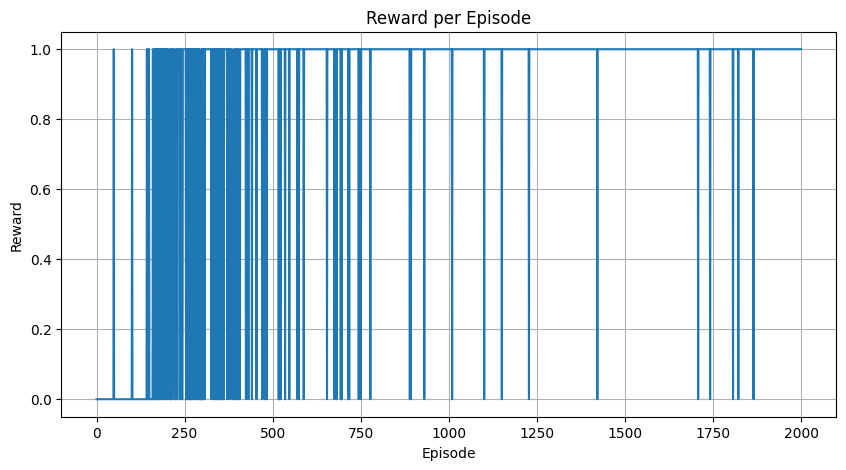

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

Langkah 9: Testing Agent

In [ ]:
env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False)

state, info = env.reset()

done = False
total_reward = 0

while not done:

    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = env.step(action)

    print(env.render())

    total_reward += reward

    done = terminated or truncated

print("Total Reward:", total_reward)

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

Total Reward: 1


1. Apa yang dimaksud dengan State, Action, dan Reward dalam Reinforcement Learning?
2. Apa fungsi dari Learning Rate (α)?
3. Apa fungsi dari Discount Factor (γ)?
4. Mengapa digunakan metode Exploration dan Exploitation?
5. Bagaimana perubahan nilai reward setelah training 2000 episode?



Tugas Lanjutan

Modifikasi program sehingga:

1. Menggunakan environment Taxi-v3
Menampilkan rata-rata reward setiap 100 episode
Membandingkan hasil training 1000, 2000, dan 5000 episode

In [ ]:
env = gym.make("Taxi-v3")

Output yang Diharapkan
Q-Table terbentuk.
Grafik reward meningkat seiring training.
Agent mampu menemukan jalur optimal menuju goal.